# COVID-19 Mortality Prediction — Machine Learning Pipeline

<p align="center">
  <img src="figures/eda_overview.png" width="900" alt="Dataset overview"/>
</p>

End-to-end **binary classification**: predict patient **death vs survival** from clinical features (~1M records).

| Step | What happens |
|------|----------------|
| 1–3 | Load, clean, train/val/test split (60/20/20) |
| 4–5 | Class weights, train **LR**, **Random Forest**, **KNN** |
| 6–8 | Compare models, ROC, radar, threshold tuning |
| 9–10 | Feature importance, final test evaluation |

> **Educational project only** — not for clinical decision-making.


## 1. Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
# Plot style for readable GitHub / notebook previews
PALETTE = {'survived': '#3498db', 'died': '#e74c3c', 'lr': '#2ecc71', 'rf': '#9b59b6', 'knn': '#f39c12'}
MODEL_COLORS = ['#2ecc71', '#9b59b6', '#f39c12']
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})



In [28]:
def plot_single_model_validation(name, y_true, y_pred, y_prob, color):
    """Bar chart + confusion matrix for one model on the validation set."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    metric_vals = [acc, prec, rec, f1, auc]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    bars = axes[0].barh(metric_names, metric_vals, color=color, edgecolor='white')
    axes[0].set_xlim(0, 1.05)
    axes[0].set_title(f'{name} — Validation Metrics', fontweight='bold')
    axes[0].axvline(0.5, color='gray', ls='--', lw=0.8, alpha=0.4)
    for b, v in zip(bars, metric_vals):
        axes[0].text(v + 0.02, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center', fontsize=9)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='PuBuGn', ax=axes[1],
                xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
    axes[1].set_title(f'{name} — Confusion Matrix', fontweight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    plt.tight_layout()
    plt.show()


## 2. Load the Raw Data

We load the original COVID-19 dataset collected from Mexican health records. Each row represents one patient, and columns capture demographics, pre-existing conditions, and treatment details.

In [29]:
df = pd.read_csv('./data/Covid_Data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1048575, 21)


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


## 3. Data Cleaning

The raw data uses a special encoding:
- **1** = Yes / True
- **2** = No / False
- **97, 98, 99** = Unknown / Not applicable

We convert this to standard binary (1/0) and treat unknowns as missing values. We also create the **DEATH** target column from `DATE_DIED`.

In [30]:
df.rename(columns={
    'SEX': 'GENDER',
    'MEDICAL_UNIT': 'MEDICAL_TYPE',
    'PATIENT_TYPE': 'TREATMENT_TYPE',
    'CLASIFFICATION_FINAL': 'COVID_RES'
}, inplace=True)

df['DEATH'] = (df['DATE_DIED'] != '9999-99-99').astype(int)
df.drop(columns='DATE_DIED', inplace=True)

print(f'Target distribution:')
print(df['DEATH'].value_counts())
print(f'\nDeath rate: {df["DEATH"].mean():.2%}')

Target distribution:
DEATH
0    971633
1     76942
Name: count, dtype: int64

Death rate: 7.34%


In [31]:
def fix_unknown(df, columns):
    """Convert 1->1, 2->0, everything else->NaN for boolean-coded columns."""
    for col in columns:
        df[col] = df[col].map({1: 1, 2: 0})
    return df

bool_cols = [
    'INTUBED', 'PNEUMONIA', 'GENDER', 'PREGNANT',
    'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
    'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR',
    'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU'
]

fix_unknown(df, bool_cols)

df['COVID_RES'] = df['COVID_RES'].apply(lambda x: 0 if x >= 4 else x)

### 3.1 Handle Missing Values

Some columns have a large proportion of missing values after cleaning (e.g., `ICU`, `INTUBED`, `PREGNANT`). We drop columns where more than 40% of values are missing, then drop remaining rows with any NaN.

In [32]:
missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing value percentage per column:\n')
print(missing_pct[missing_pct > 0].apply(lambda x: f'{x:.1%}'))

Missing value percentage per column:

ICU               81.6%
INTUBED           81.6%
PREGNANT          50.3%
PNEUMONIA          1.5%
OTHER_DISEASE      0.5%
INMSUPR            0.3%
DIABETES           0.3%
TOBACCO            0.3%
HIPERTENSION       0.3%
CARDIOVASCULAR     0.3%
OBESITY            0.3%
RENAL_CHRONIC      0.3%
COPD               0.3%
ASTHMA             0.3%
dtype: str


In [33]:
high_missing = missing_pct[missing_pct > 0.40].index.tolist()
print(f'Dropping columns with >40% missing: {high_missing}')
df.drop(columns=high_missing, inplace=True)

rows_before = len(df)
df.dropna(inplace=True)
rows_after = len(df)
print(f'Dropped {rows_before - rows_after:,} rows with remaining NaN values')
print(f'Final dataset shape: {df.shape}')

Dropping columns with >40% missing: ['ICU', 'INTUBED', 'PREGNANT']
Dropped 23,423 rows with remaining NaN values
Final dataset shape: (1025152, 18)


In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 1025152 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   USMER           1025152 non-null  int64  
 1   MEDICAL_TYPE    1025152 non-null  int64  
 2   GENDER          1025152 non-null  int64  
 3   TREATMENT_TYPE  1025152 non-null  int64  
 4   PNEUMONIA       1025152 non-null  float64
 5   AGE             1025152 non-null  int64  
 6   DIABETES        1025152 non-null  float64
 7   COPD            1025152 non-null  float64
 8   ASTHMA          1025152 non-null  float64
 9   INMSUPR         1025152 non-null  float64
 10  HIPERTENSION    1025152 non-null  float64
 11  OTHER_DISEASE   1025152 non-null  float64
 12  CARDIOVASCULAR  1025152 non-null  float64
 13  OBESITY         1025152 non-null  float64
 14  RENAL_CHRONIC   1025152 non-null  float64
 15  TOBACCO         1025152 non-null  float64
 16  COVID_RES       1025152 non-null  int64  
 17  DEATH

## 4. Prepare Features and Target

We separate the dataset into:
- **X** — all feature columns (everything except DEATH)
- **y** — the target column (DEATH: 0 = survived, 1 = died)

In [35]:
X = df.drop(columns='DEATH')
y = df['DEATH']

print(f'Features: {X.shape[1]} columns')
print(f'Samples:  {X.shape[0]:,}')
print(f'\nTarget distribution:')
print(y.value_counts())
print(f'\nClass balance — Death rate: {y.mean():.2%}')

Features: 17 columns
Samples:  1,025,152

Target distribution:
DEATH
0    950438
1     74714
Name: count, dtype: int64

Class balance — Death rate: 7.29%


### 4.1 Exploratory Visualizations

Quick look at the **target imbalance**, **age vs. mortality**, and **feature correlations** before modeling.

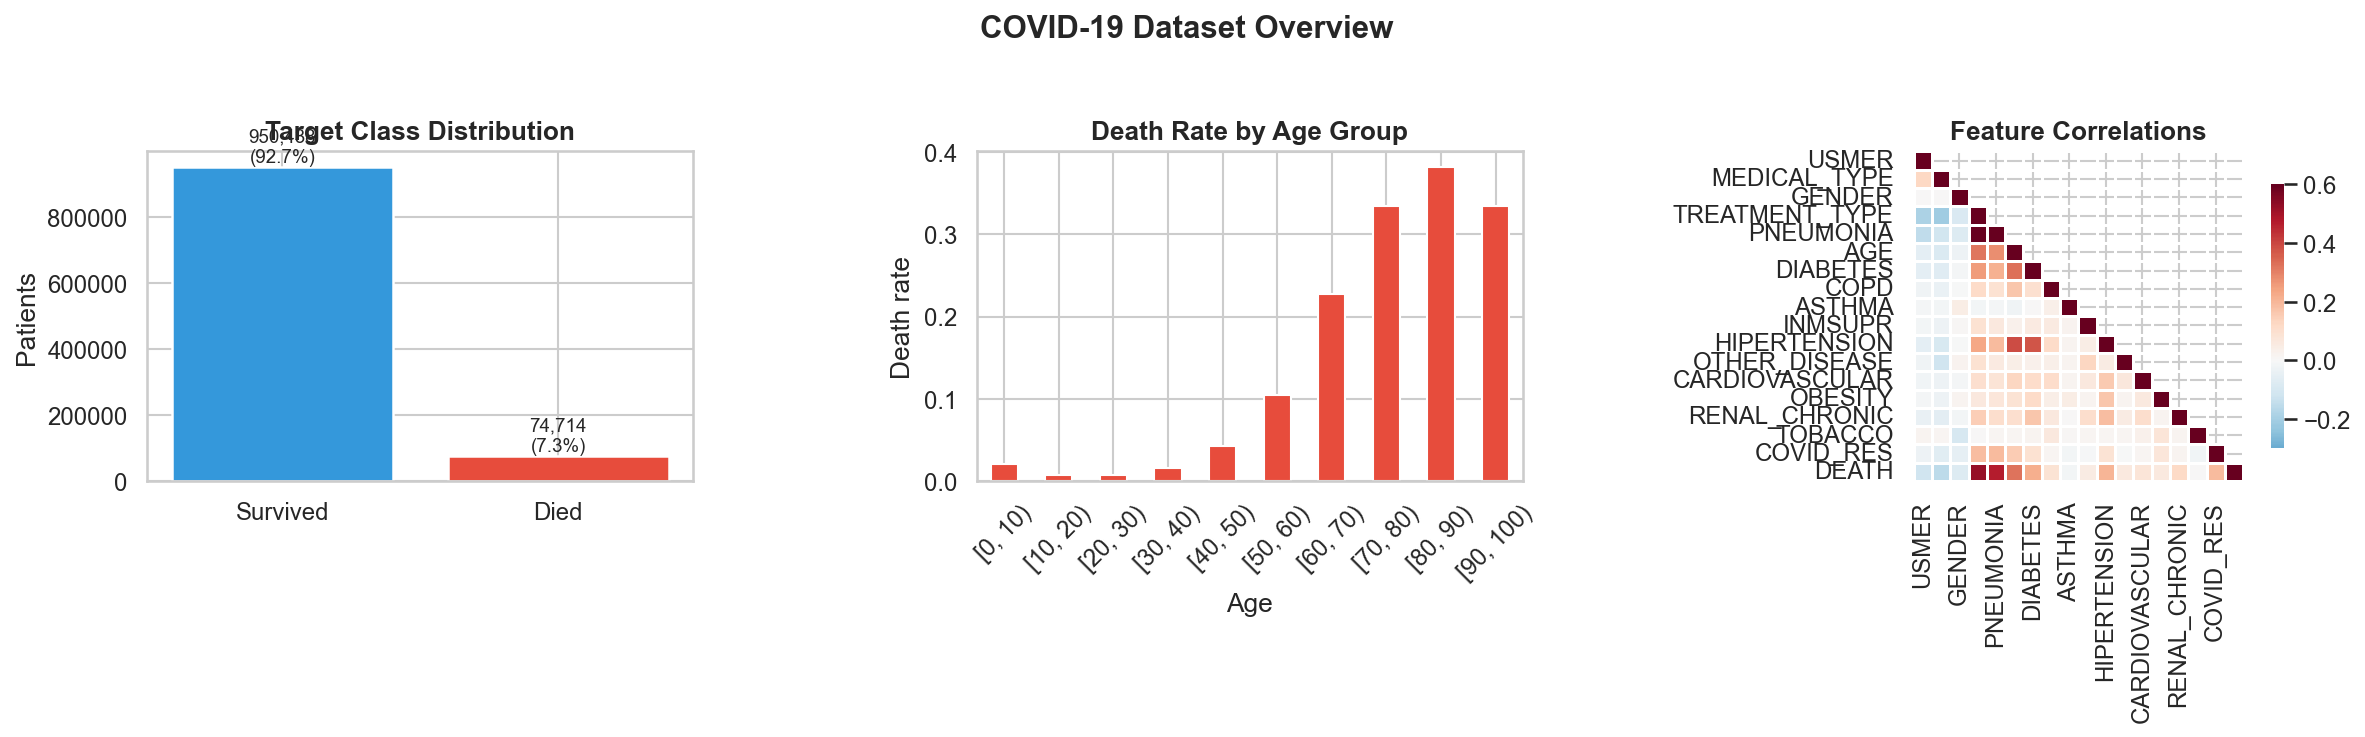

In [36]:
death_counts = y.value_counts().sort_index()
labels = ['Survived', 'Died']
colors = [PALETTE['survived'], PALETTE['died']]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Target balance
axes[0].bar(labels, death_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Patients')
for i, v in enumerate(death_counts.values):
    axes[0].text(i, v + 15000, f'{v:,}\n({v/len(y):.1%})', ha='center', fontsize=9)

# Death rate by age (binned)
age_death = df.groupby(pd.cut(df['AGE'], bins=range(0, 105, 10), right=False))['DEATH'].mean()
age_death.plot(kind='bar', ax=axes[1], color=PALETTE['died'], edgecolor='white')
axes[1].set_title('Death Rate by Age Group', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Death rate')
axes[1].tick_params(axis='x', rotation=45)

# Correlation heatmap (numeric features)
num_cols = [c for c in df.columns if c != 'DEATH' and df[c].dtype in ('int64', 'float64')]
corr = df[num_cols + ['DEATH']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.6,
            square=True, linewidths=0.5, ax=axes[2], cbar_kws={'shrink': 0.8})
axes[2].set_title('Feature Correlations', fontweight='bold')

plt.suptitle('COVID-19 Dataset Overview', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split

We split the data into three sets:
- **Training (60%)** — used to train the models
- **Validation (20%)** — used to compare models and tune the classification threshold
- **Test (20%)** — held out until the very end for final, unbiased evaluation

All splits use `stratify=y` to preserve the class distribution.

In [37]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f'Training set:   {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X):.0%})')
print(f'Validation set: {X_val.shape[0]:,} samples  ({X_val.shape[0]/len(X):.0%})')
print(f'Test set:       {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(X):.0%})')
print(f'\nDeath rates — Train: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | Test: {y_test.mean():.2%}')

Training set:   615,090 samples  (60%)
Validation set: 205,031 samples  (20%)
Test set:       205,031 samples  (20%)

Death rates — Train: 7.29% | Val: 7.29% | Test: 7.29%


### 5.1 Feature Scaling

Logistic Regression benefits from standardized features (mean=0, std=1). We fit the scaler **on the training set only** and then transform validation and test sets using the same scaler — this prevents data leakage.

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 6. Handle Class Imbalance

The death rate is only ~7%, meaning the dataset is **heavily imbalanced**. A naive model that always predicts "survived" would achieve ~93% accuracy but miss every death.

Since this is a **medical-risk classification**, missing a true death case (false negative) is far worse than a false alarm (false positive). We need to optimize for **recall** — catching as many death cases as possible.

**Strategy:** We use `class_weight='balanced'` in Logistic Regression and Random Forest, which automatically gives more importance to the minority class (deaths) during training. KNN does not support class weights directly, but benefits from the overall pipeline design (stratified splits, threshold tuning).

## 7. Model Training

We compare **three classifiers** that represent different learning strategies. All are trained on the same train/validation/test split and evaluated with the same metrics.

| Model | Type | Strengths | Limitations |
|-------|------|-----------|-------------|
| **Logistic Regression** | Linear | Fast, interpretable coefficients, strong ROC-AUC here | Assumes linear decision boundary |
| **Random Forest** | Ensemble (200 trees) | Captures non-linear patterns, robust to outliers | Less interpretable, slower to train |
| **K-Nearest Neighbors (KNN)** | Instance-based | Simple idea: similar patients → similar outcome | Slow on large data; no `class_weight`; needs scaling |

**Shared settings:** stratified splits, `class_weight='balanced'` where supported (LR & RF), default threshold 0.5 for initial validation reports below.

### 7.1 Logistic Regression

**What it does:** Estimates the log-odds of death as a weighted sum of features. After training, each coefficient shows whether a feature pushes risk up or down.

**Why we use it:** Strong baseline for tabular medical data; easy to explain; works well with scaled features and class weights on imbalanced data.

**Hyperparameters used:** `class_weight='balanced'`, `max_iter=1000` (no grid search — educational baseline).

In [39]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

lr_val_pred = lr_model.predict(X_val_scaled)
lr_val_prob = lr_model.predict_proba(X_val_scaled)[:, 1]

print('Logistic Regression — Validation Report:\n')
print(classification_report(y_val, lr_val_pred, target_names=['Survived', 'Died']))

Logistic Regression — Validation Report:

              precision    recall  f1-score   support

    Survived       0.99      0.89      0.94    190088
        Died       0.40      0.92      0.56     14943

    accuracy                           0.89    205031
   macro avg       0.70      0.91      0.75    205031
weighted avg       0.95      0.89      0.91    205031



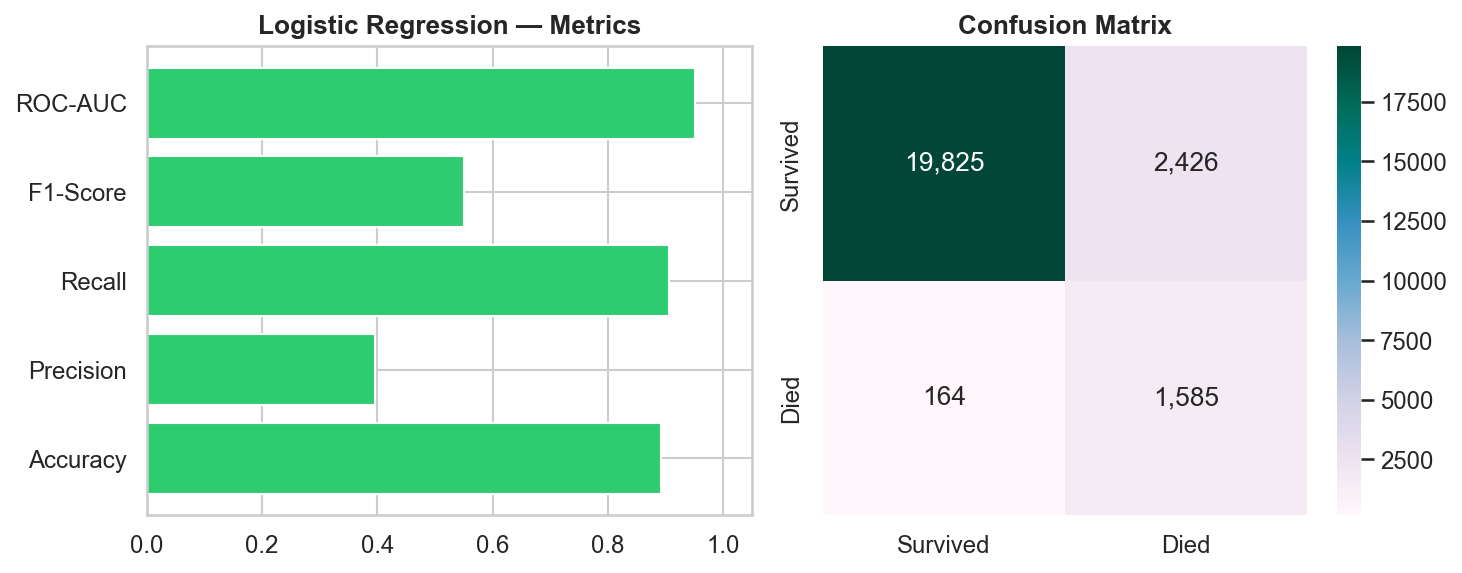

In [40]:
plot_single_model_validation(
    'Logistic Regression', y_val, lr_val_pred, lr_val_prob, MODEL_COLORS[0]
)


### 7.2 Random Forest

**What it does:** Builds many decision trees on random subsets of data and features, then averages their votes. Can model interactions (e.g., high age + pneumonia).

**Why we use it:** Often improves over linear models when relationships are non-linear; handles mixed feature types without scaling.

**Hyperparameters used:** `n_estimators=200`, `class_weight='balanced'`, `n_jobs=-1`.

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)
rf_val_prob = rf_model.predict_proba(X_val)[:, 1]

print('Random Forest — Validation Report:\n')
print(classification_report(y_val, rf_val_pred, target_names=['Survived', 'Died']))

Random Forest — Validation Report:

              precision    recall  f1-score   support

    Survived       0.98      0.91      0.95    190088
        Died       0.41      0.78      0.54     14943

    accuracy                           0.90    205031
   macro avg       0.70      0.85      0.74    205031
weighted avg       0.94      0.90      0.92    205031



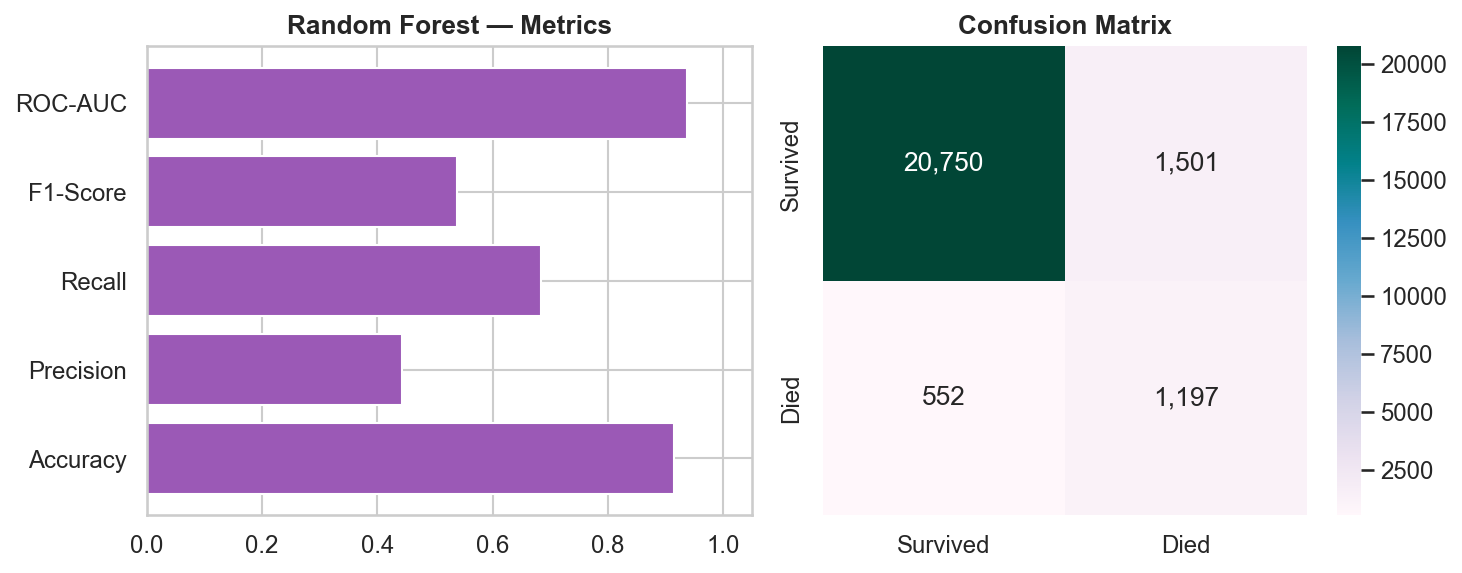

In [42]:
plot_single_model_validation(
    'Random Forest', y_val, rf_val_pred, rf_val_prob, MODEL_COLORS[1]
)

### 7.3 K-Nearest Neighbors (KNN)

**What it does:** For each patient, finds the **K=5** closest training patients (Euclidean distance on scaled features) and predicts death if most neighbors died.

**Why we use it:** Non-parametric benchmark — no explicit training phase, but prediction is expensive on ~600k training rows.

**Note:** KNN does not support `class_weight`; we rely on stratified sampling and later **threshold tuning** to improve recall.

In [43]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_val_pred = knn_model.predict(X_val_scaled)
knn_val_prob = knn_model.predict_proba(X_val_scaled)[:, 1]

print('K-Nearest Neighbors — Validation Report:\n')
print(classification_report(y_val, knn_val_pred, target_names=['Survived', 'Died']))

K-Nearest Neighbors — Validation Report:

              precision    recall  f1-score   support

    Survived       0.96      0.97      0.96    190088
        Died       0.54      0.44      0.49     14943

    accuracy                           0.93    205031
   macro avg       0.75      0.71      0.72    205031
weighted avg       0.93      0.93      0.93    205031



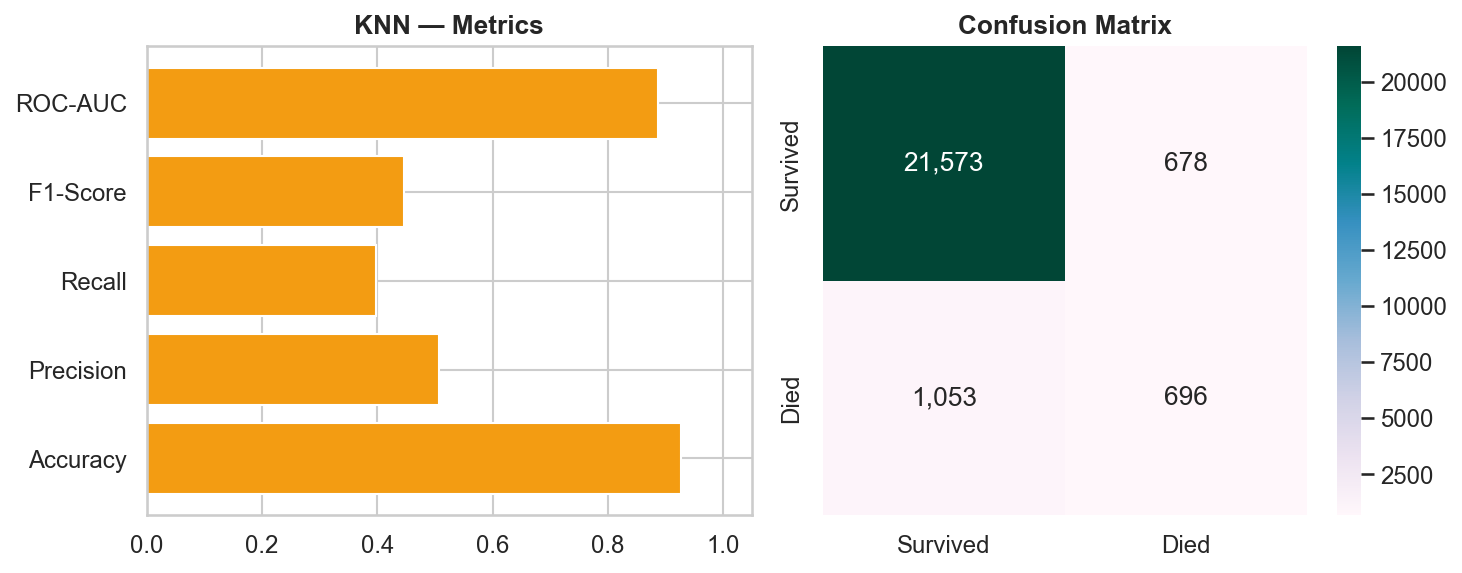

In [44]:
plot_single_model_validation(
    'KNN', y_val, knn_val_pred, knn_val_prob, MODEL_COLORS[2]
)

## 8. Model Evaluation & Comparison (Validation Set)

All three models are compared on the **same validation set** (never used for training). We care most about **recall** (catching deaths) and **ROC-AUC** (ranking risk), not accuracy alone.

**How to read the charts below:**
- **Bar chart** — compare metrics across models at a glance
- **Confusion matrices** — false negatives (missed deaths) are bottom-left; false positives are top-right
- **ROC curves** — higher and farther left is better; area under curve = ROC-AUC
- **Radar chart** — Recall, F1, and ROC-AUC together (three models overlaid)

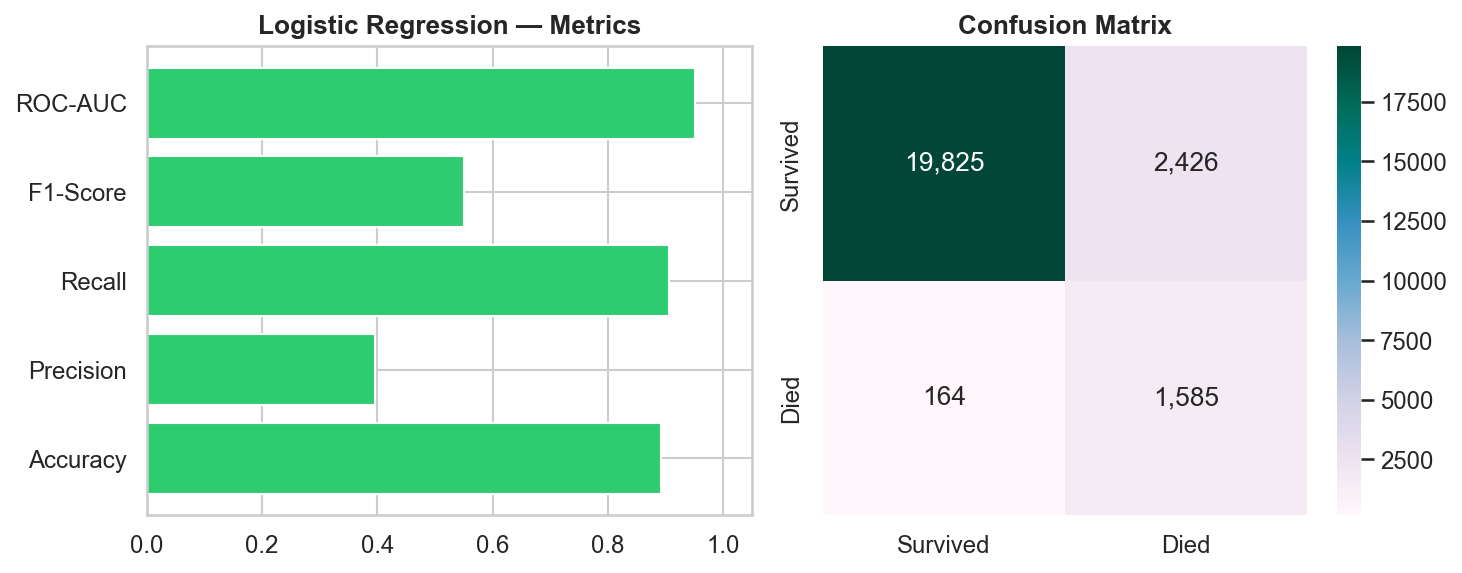

In [45]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """Calculate all evaluation metrics for a model."""
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_val, lr_val_pred, lr_val_prob),
    evaluate_model('Random Forest', y_val, rf_val_pred, rf_val_prob),
    evaluate_model('KNN', y_val, knn_val_pred, knn_val_prob)
])

results = results.set_index('Model')
results.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen')

### 8.0 Validation Metrics Table

In [46]:
# Annotated comparison table (validation) — green = best per column
results.style.format('{:.4f}') \
    .background_gradient(cmap='RdYlGn', subset=['Recall', 'F1-Score', 'ROC-AUC'], vmin=0.4, vmax=1.0) \
    .highlight_max(axis=0, color='#d5f5e3')


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8931,0.3988,0.9207,0.5566,0.9531
Random Forest,0.9034,0.4140,0.7846,0.5420,0.9345
KNN,0.9319,0.5404,0.4418,0.4861,0.8974


### 8.1 Model Comparison — Bar Chart

Visual comparison of key metrics across all three models.

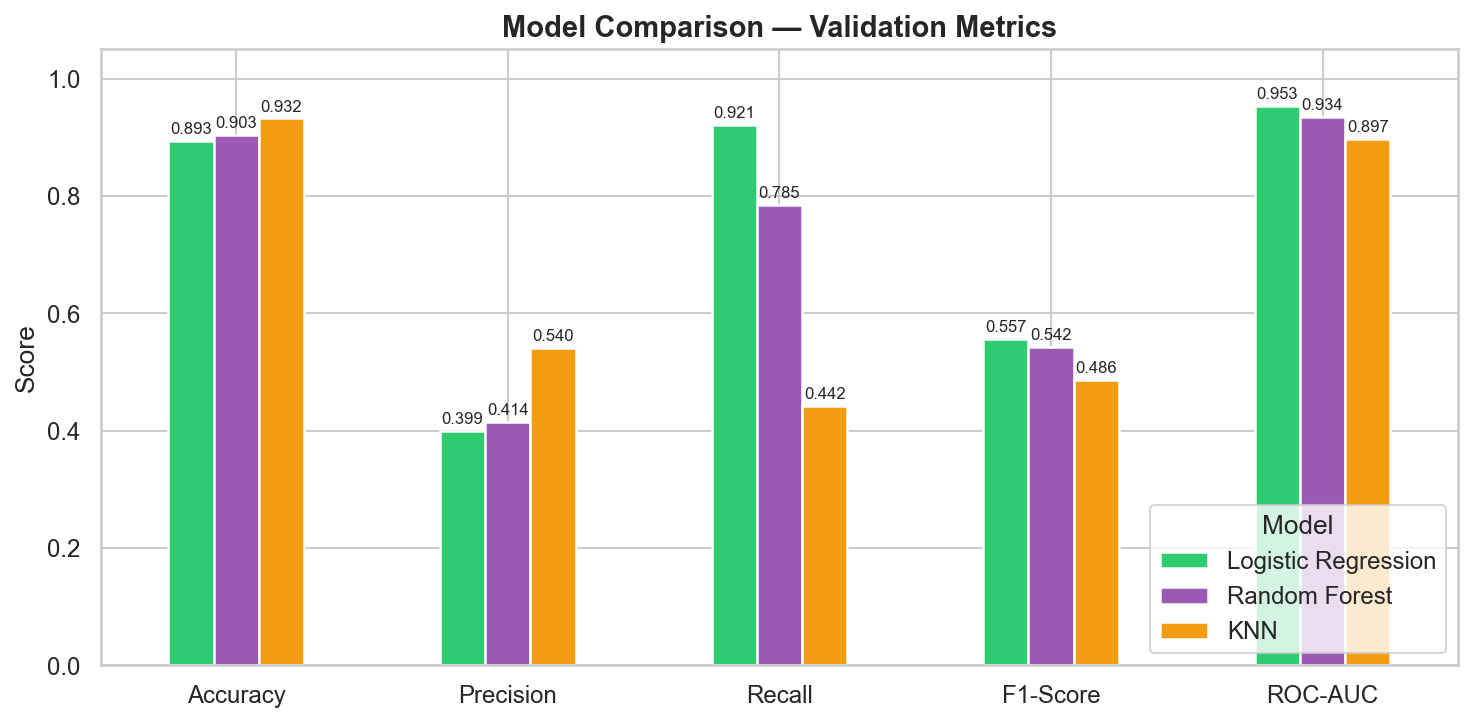

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))

results.T.plot(kind='bar', ax=ax, rot=0, color=MODEL_COLORS, edgecolor='white', linewidth=1.2)

ax.set_title('Model Comparison — Validation Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(title='Model', loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

### 8.2 How We Interpret the Three Models

| Model | Best at | Trade-off |
|-------|---------|-----------|
| **Logistic Regression** | **Highest recall (0.92)** and **ROC-AUC (0.95)** — best at ranking who is high-risk | Lower precision: more false alarms |
| **Random Forest** | Strong accuracy and non-linear patterns | Lower recall than LR; still competitive F1 |
| **KNN** | Highest accuracy & precision on validation | **Lowest recall** — misses more true deaths; expensive at scale |

**Selection rule:** Pick the model with the best validation **ROC-AUC**, then tune the **classification threshold** on validation (maximize F1) before one final test evaluation.

### 8.3 Confusion Matrices

The confusion matrix shows how many predictions fall into each category:
- **True Negative (TN):** Correctly predicted survival
- **False Positive (FP):** Predicted death but patient survived
- **False Negative (FN):** Predicted survival but patient died ← *the most dangerous error*
- **True Positive (TP):** Correctly predicted death

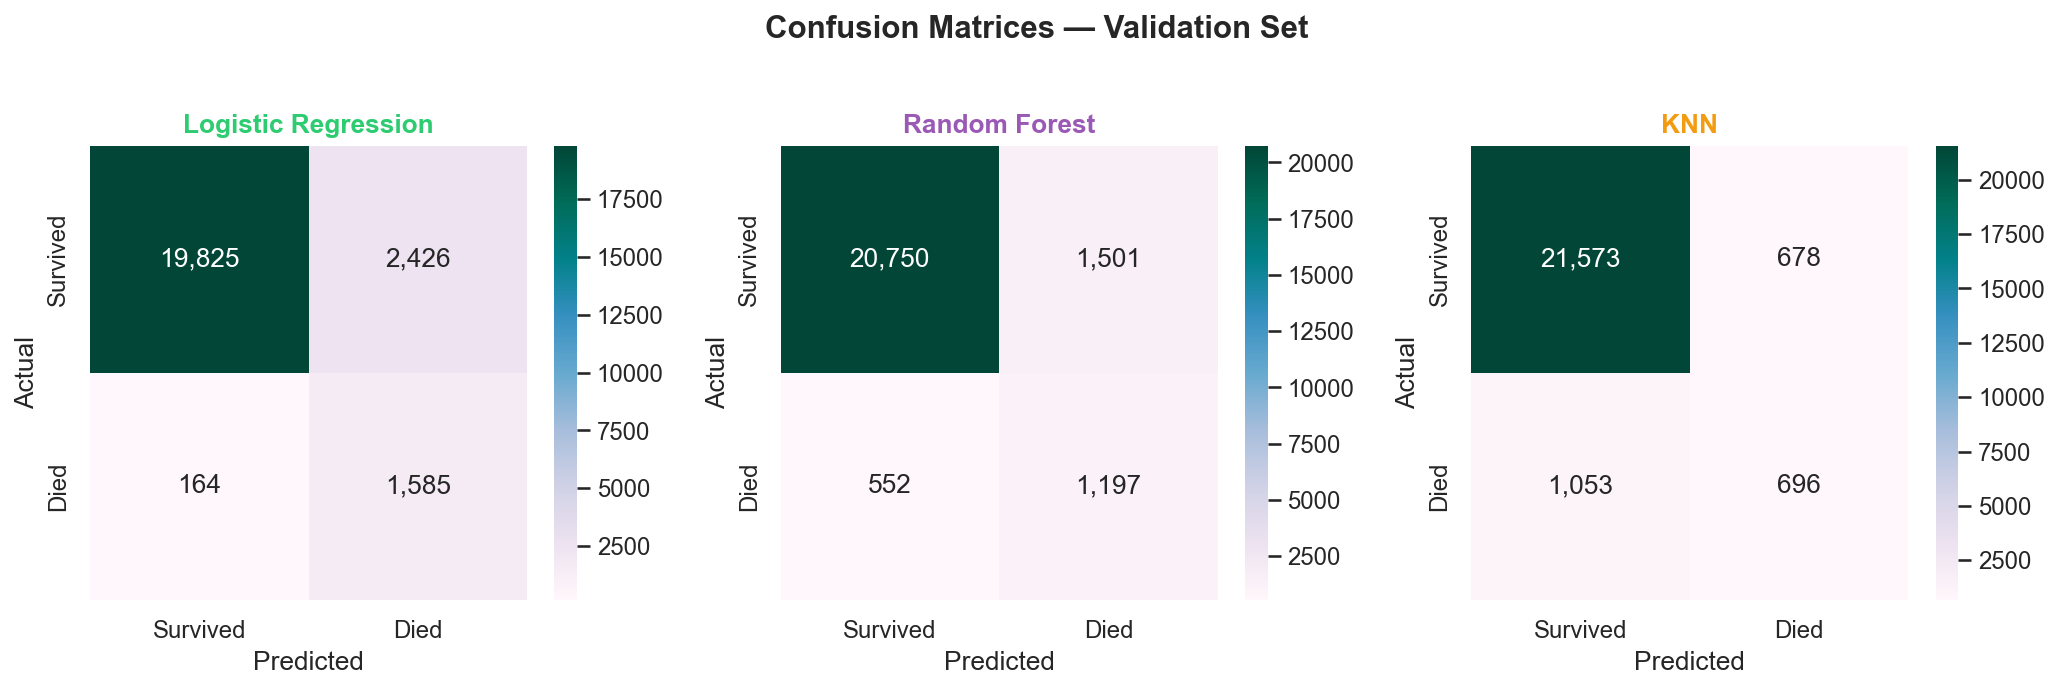

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Logistic Regression', lr_val_pred),
    ('Random Forest', rf_val_pred),
    ('KNN', knn_val_pred)
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm, annot=True, fmt=',d', cmap='Blues',
        xticklabels=['Survived', 'Died'],
        yticklabels=['Survived', 'Died'],
        ax=ax
    )
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Validation Set)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.4 ROC Curves

The ROC curve shows the trade-off between the true positive rate (recall) and false positive rate at different classification thresholds. A higher AUC indicates better overall discrimination ability.

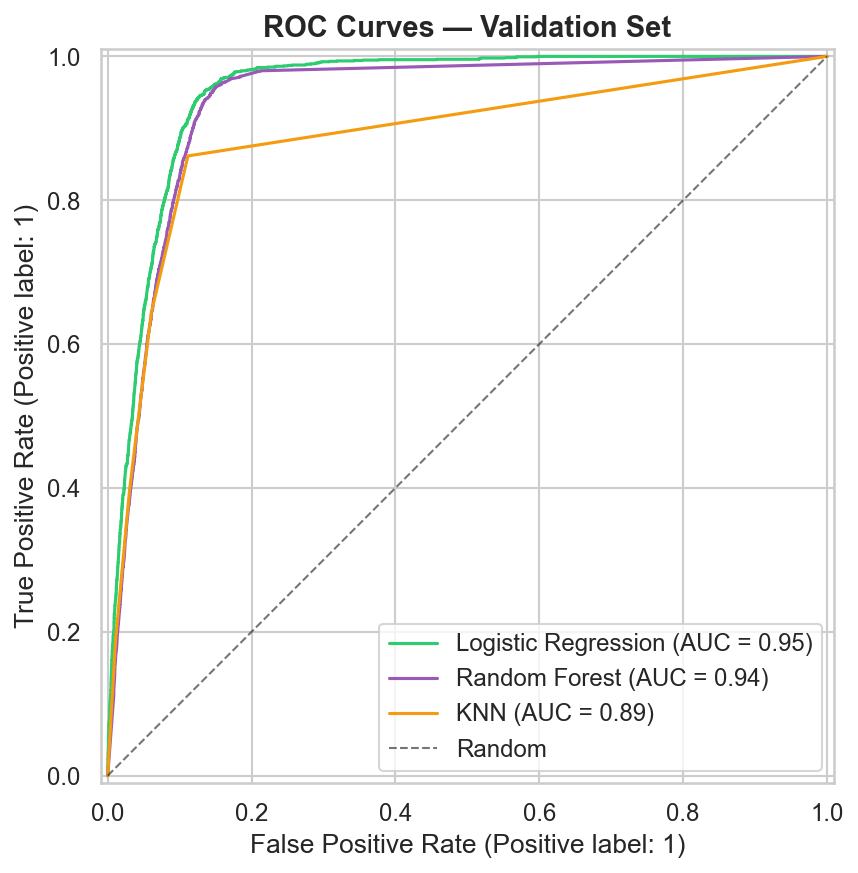

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_val, lr_val_prob, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_val, rf_val_prob, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_val, knn_val_prob, name='KNN', ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_title('ROC Curves — Validation Set', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 8.5 Model Profile Radar Chart

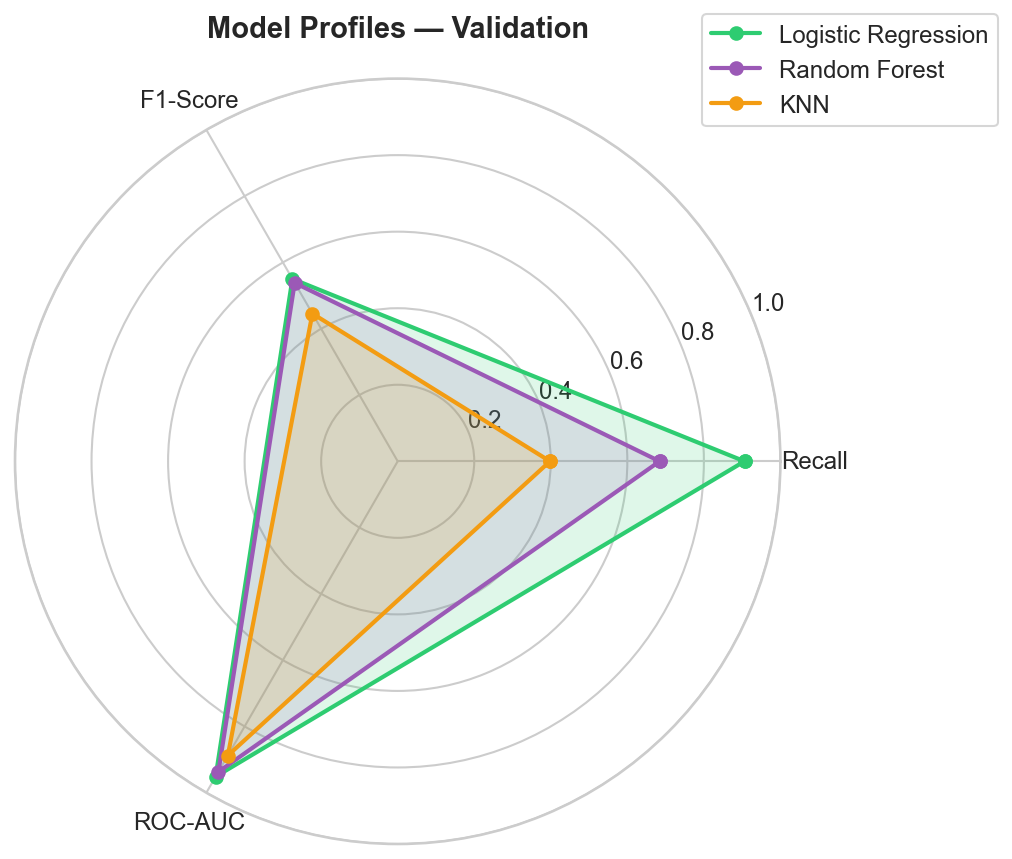

In [50]:
# Radar chart: Recall, F1, ROC-AUC per model (validation)
radar_metrics = ['Recall', 'F1-Score', 'ROC-AUC']
radar_df = results[radar_metrics]
labels = radar_metrics
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, (model_name, row) in enumerate(radar_df.iterrows()):
    vals = row.values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model_name, color=MODEL_COLORS[i])
    ax.fill(angles, vals, alpha=0.12, color=MODEL_COLORS[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title('Model Profiles — Validation Set\n(higher = better)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()


### 8.6 Cross-Validation on Training Set

**StratifiedKFold cross-validation** splits the training data into 5 folds and trains/evaluates the model 5 times, each time using a different fold as validation. This gives a more reliable estimate of model performance.

For Logistic Regression and KNN, we wrap the scaler and model in a **sklearn Pipeline** so that scaling is applied correctly inside each fold (no data leakage between folds).

**Note:** KNN cross-validation runs on a stratified subsample of at most 50,000 rows because KNN is computationally expensive on large datasets (O(n) distance computations per prediction).

In [51]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# KNN CV uses a stratified subsample (max 50k rows) because KNN is
# computationally expensive on large datasets (O(n) per prediction).
KNN_CV_MAX_ROWS = 50_000
if len(X_train) > KNN_CV_MAX_ROWS:
    from sklearn.model_selection import train_test_split as _tts
    X_train_knn_cv, _, y_train_knn_cv, _ = _tts(
        X_train, y_train, train_size=KNN_CV_MAX_ROWS,
        stratify=y_train, random_state=42
    )
    knn_cv_note = f' (on stratified sample of {KNN_CV_MAX_ROWS:,} rows)'
else:
    X_train_knn_cv, y_train_knn_cv = X_train, y_train
    knn_cv_note = ''

cv_models = {
    'Logistic Regression': (lr_pipeline, X_train, y_train),
    'Random Forest': (RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1), X_train, y_train),
    'KNN': (Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]), X_train_knn_cv, y_train_knn_cv)
}

cv_results = []
for name, (model, data, target) in cv_models.items():
    scores = cross_val_score(model, data, target, cv=cv, scoring='f1', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'Mean F1': scores.mean(),
        'Std F1': scores.std(),
        'Folds': scores
    })
    print(f'{name:<25s} — CV F1: {scores.mean():.4f} (+/- {scores.std():.4f})')

print('\nAll models show consistent F1 scores across folds (low std), confirming stable performance.')

Logistic Regression       — CV F1: 0.5573 (+/- 0.0021)
Random Forest             — CV F1: 0.5448 (+/- 0.0018)
KNN                       — CV F1: 0.4548 (+/- 0.0075)

All models show consistent F1 scores across folds (low std), confirming stable performance.


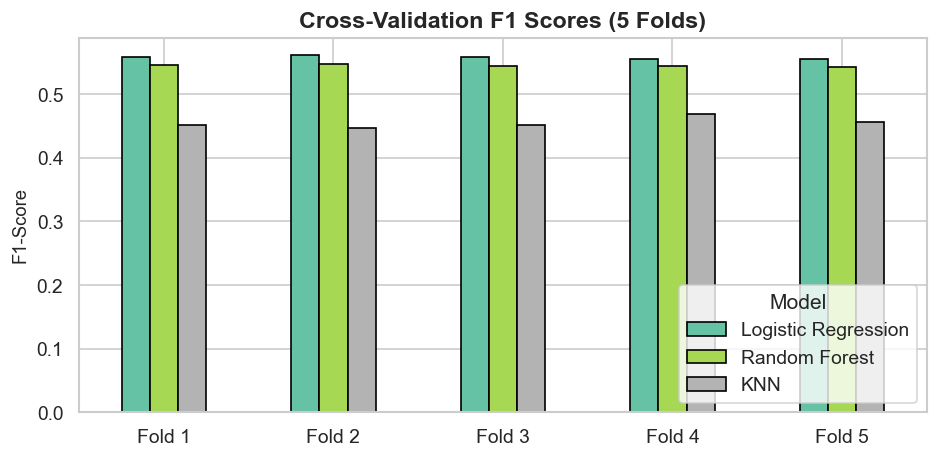

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))

cv_df = pd.DataFrame({r['Model']: r['Folds'] for r in cv_results})
cv_df.index = [f'Fold {i+1}' for i in range(5)]

cv_df.plot(kind='bar', ax=ax, rot=0, colormap='Set2', edgecolor='black')

ax.set_title('Cross-Validation F1 Scores (5 Folds)', fontsize=14, fontweight='bold')
ax.set_ylabel('F1-Score')
ax.legend(title='Model', loc='lower right')

plt.tight_layout()
plt.show()

### 8.7 Threshold Tuning (Validation Set)

By default, classifiers use a **0.5 probability threshold** — if the predicted probability of death is ≥ 0.5, the model predicts "died". But for medical-risk classification, we may want to **lower the threshold** to catch more true death cases (higher recall), even at the cost of more false alarms (lower precision).

We test thresholds of 0.3, 0.4, 0.5, and 0.6 on the **validation set** to find the optimal balance. The test set is not touched here.

In [53]:
best_auc_model = results['ROC-AUC'].idxmax()
val_probs = {
    'Logistic Regression': lr_val_prob,
    'Random Forest': rf_val_prob,
    'KNN': knn_val_prob
}
best_val_prob = val_probs[best_auc_model]

print(f'Threshold tuning on: {best_auc_model} (highest validation ROC-AUC)\n')

thresholds = [0.3, 0.4, 0.5, 0.6]
threshold_results = []

for t in thresholds:
    preds = (best_val_prob >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_val, preds),
        'Recall': recall_score(y_val, preds),
        'F1-Score': f1_score(y_val, preds)
    })

threshold_df = pd.DataFrame(threshold_results).set_index('Threshold')
threshold_df.style.format('{:.4f}').highlight_max(axis=0, subset=['Recall', 'F1-Score'], color='lightgreen')

Threshold tuning on: Logistic Regression (highest validation ROC-AUC)



,Precision,Recall,F1-Score
Threshold,,,
0.300000,0.3561,0.9550,0.5188
0.400000,0.3810,0.9402,0.5422
0.500000,0.3988,0.9207,0.5566
0.600000,0.4153,0.8965,0.5676


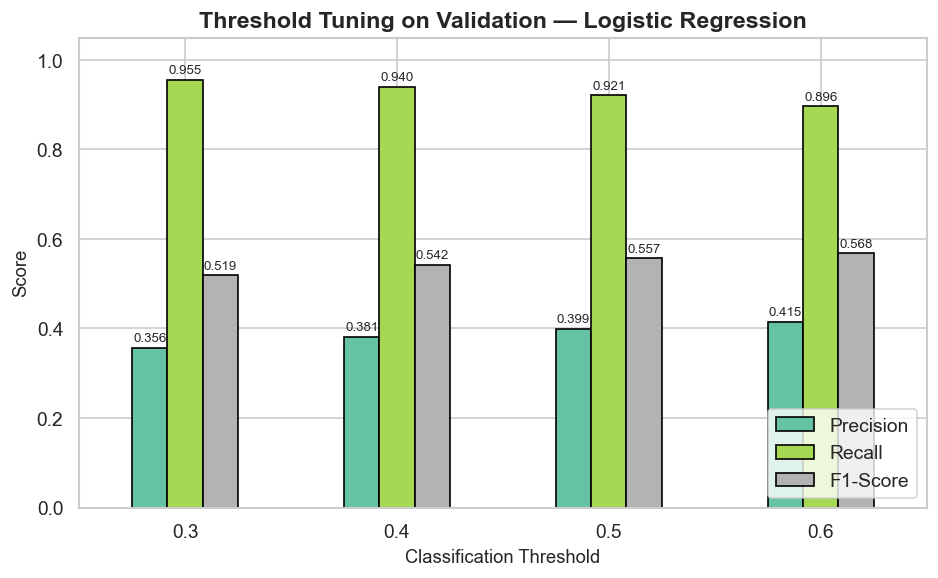

Interpretation:
- Lower threshold (0.3) → higher recall (catches more deaths) but lower precision (more false alarms)
- Higher threshold (0.6) → higher precision but lower recall (misses more deaths)
- For medical risk: a lower threshold is preferred because missing a death case is more dangerous than a false alarm


In [54]:
fig, ax = plt.subplots(figsize=(8, 5))

threshold_df.plot(kind='bar', ax=ax, rot=0, colormap='Set2', edgecolor='black')

ax.set_title(f'Threshold Tuning on Validation — {best_auc_model}', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Classification Threshold')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

print('Interpretation:')
print('- Lower threshold (0.3) → higher recall (catches more deaths) but lower precision (more false alarms)')
print('- Higher threshold (0.6) → higher precision but lower recall (misses more deaths)')
print('- For medical risk: a lower threshold is preferred because missing a death case is more dangerous than a false alarm')

## 9. Feature Importance Analysis

Understanding which features contribute most to the prediction is critical in medical contexts. We analyze feature importance from two perspectives:
- **Logistic Regression coefficients** — show direction and strength of each feature's effect
- **Random Forest feature importances** — show how much each feature contributes to tree splits

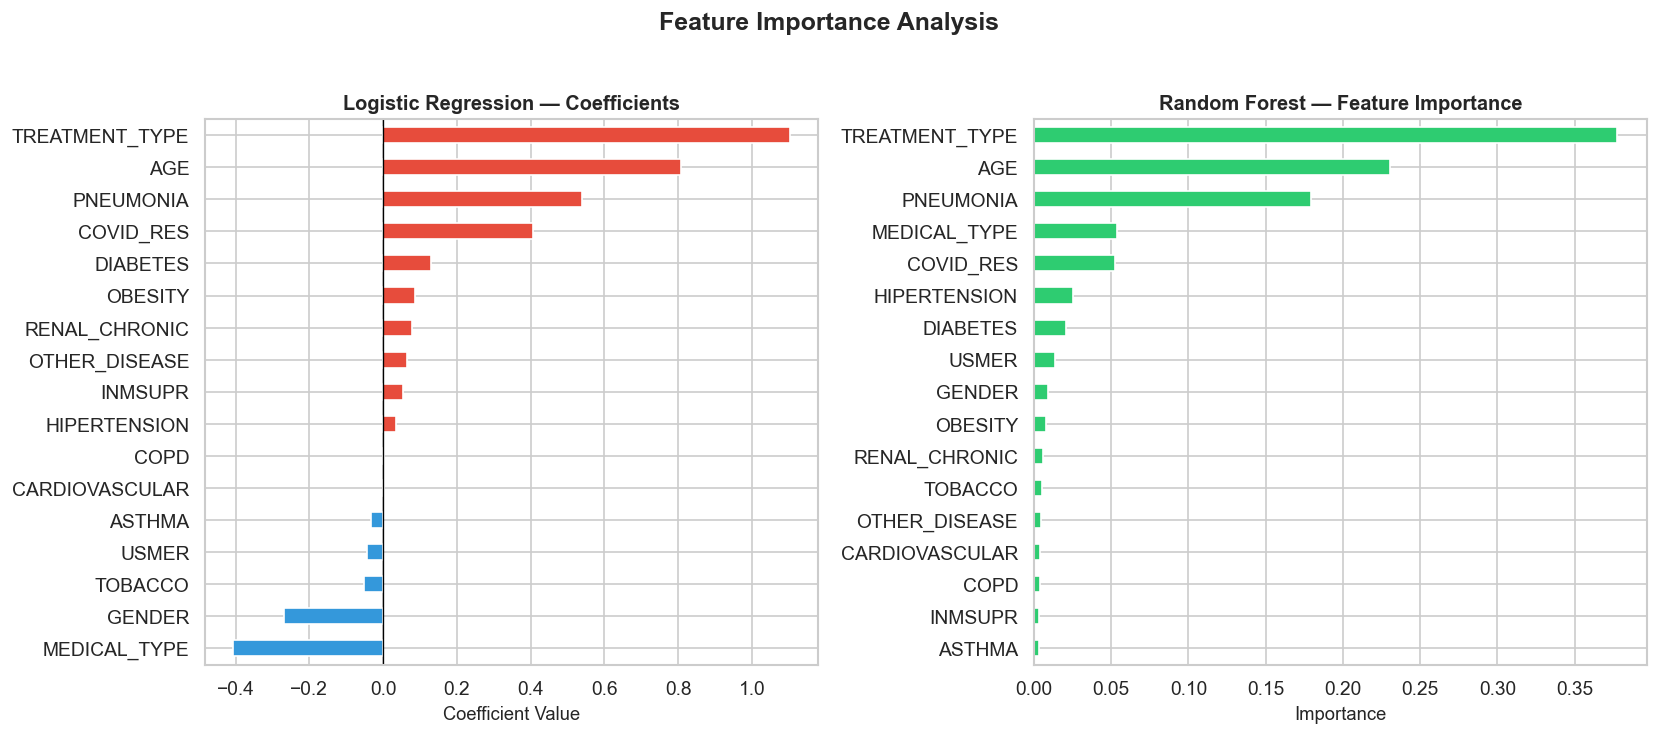

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression coefficients
lr_importance = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()
lr_importance.plot(kind='barh', ax=axes[0], color=lr_importance.apply(
    lambda x: '#e74c3c' if x > 0 else '#3498db'
))
axes[0].set_title('Logistic Regression — Coefficients', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Random Forest feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
rf_importance.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Random Forest — Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.1 Top Predictive Features

Let's summarize the most important features for predicting COVID-19 mortality.

In [56]:
top_features = rf_importance.sort_values(ascending=False).head(5)
print('Top 5 features for predicting COVID-19 mortality (Random Forest):\n')
for i, (feature, importance) in enumerate(top_features.items(), 1):
    print(f'  {i}. {feature:<20s} — importance: {importance:.4f}')

Top 5 features for predicting COVID-19 mortality (Random Forest):

  1. TREATMENT_TYPE       — importance: 0.3778
  2. AGE                  — importance: 0.2306
  3. PNEUMONIA            — importance: 0.1791
  4. MEDICAL_TYPE         — importance: 0.0539
  5. COVID_RES            — importance: 0.0522


### Validation Results Summary

Before moving to the final test evaluation, let's summarize which model performed best on the validation set.

In [57]:
print('VALIDATION SET — MODEL COMPARISON')
print('=' * 65)
print(f'\n{results.to_string()}\n')
print(f'Best by Recall:  {results["Recall"].idxmax():<25s} ({results["Recall"].max():.4f})')
print(f'Best by F1:      {results["F1-Score"].idxmax():<25s} ({results["F1-Score"].max():.4f})')
print(f'Best by ROC-AUC: {results["ROC-AUC"].idxmax():<25s} ({results["ROC-AUC"].max():.4f})')
print(f'\n→ Selected for final test: {results["ROC-AUC"].idxmax()} (threshold={threshold_df["F1-Score"].idxmax()})')

VALIDATION SET — MODEL COMPARISON

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                                 
Logistic Regression  0.893070   0.398817  0.920699  0.556553  0.953130
Random Forest        0.903356   0.413983  0.784581  0.541987  0.934497
KNN                  0.931927   0.540350  0.441812  0.486138  0.897419

Best by Recall:  Logistic Regression       (0.9207)
Best by F1:      Logistic Regression       (0.5566)
Best by ROC-AUC: Logistic Regression       (0.9531)

→ Selected for final test: Logistic Regression (threshold=0.6)


## 10. Final Model Selection & Test Evaluation

All model comparison and threshold tuning was done on the **validation set**. Now we apply the selected model and threshold to the **held-out test set** for a final, unbiased evaluation.

In [58]:
selected_model_name = results['ROC-AUC'].idxmax()
selected_threshold = threshold_df['F1-Score'].idxmax()

models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'KNN': knn_model
}
selected_model = models_dict[selected_model_name]

if selected_model_name in ('Logistic Regression', 'KNN'):
    test_prob = selected_model.predict_proba(X_test_scaled)[:, 1]
else:
    test_prob = selected_model.predict_proba(X_test)[:, 1]

test_pred = (test_prob >= selected_threshold).astype(int)

test_acc = accuracy_score(y_test, test_pred)
test_prec = precision_score(y_test, test_pred)
test_rec = recall_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)

print('=' * 65)
print('FINAL RESULTS ON HELD-OUT TEST SET')
print('=' * 65)
print(f'\n  Selected model:     {selected_model_name}')
print(f'  Selected threshold: {selected_threshold}')
print(f'  Reason:             Highest validation ROC-AUC ({results.loc[selected_model_name, "ROC-AUC"]:.4f}),')
print(f'                      threshold chosen by best validation F1-Score.')
print(f'\n  {"Metric":<15s} {"Test Score":>10s}')
print(f'  {"-"*27}')
print(f'  {"Accuracy":<15s} {test_acc:>10.4f}')
print(f'  {"Precision":<15s} {test_prec:>10.4f}')
print(f'  {"Recall":<15s} {test_rec:>10.4f}')
print(f'  {"F1-Score":<15s} {test_f1:>10.4f}')
print(f'  {"ROC-AUC":<15s} {test_auc:>10.4f}')

print(f'\nClassification Report (Test Set):\n')
print(classification_report(y_test, test_pred, target_names=['Survived', 'Died']))

FINAL RESULTS ON HELD-OUT TEST SET

  Selected model:     Logistic Regression
  Selected threshold: 0.6
  Reason:             Highest validation ROC-AUC (0.9531),
                      threshold chosen by best validation F1-Score.

  Metric          Test Score
  ---------------------------
  Accuracy            0.9011
  Precision           0.4168
  Recall              0.8952
  F1-Score            0.5688
  ROC-AUC             0.9539

Classification Report (Test Set):

              precision    recall  f1-score   support

    Survived       0.99      0.90      0.94    190088
        Died       0.42      0.90      0.57     14943

    accuracy                           0.90    205031
   macro avg       0.70      0.90      0.76    205031
weighted avg       0.95      0.90      0.92    205031



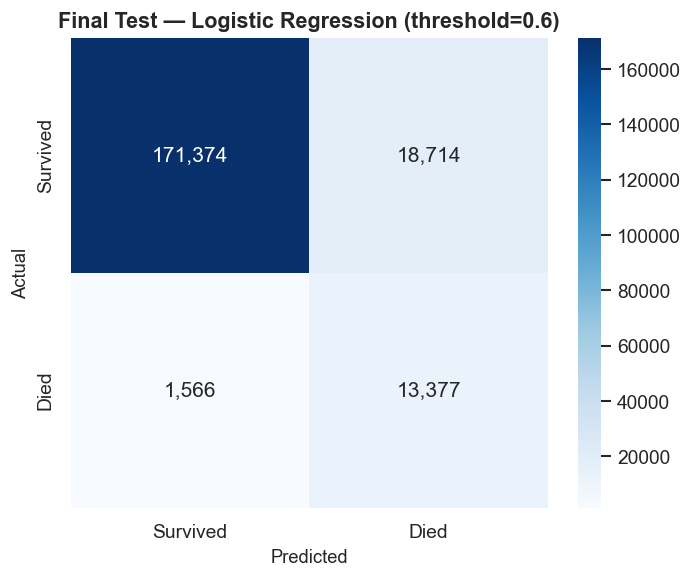

In [59]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_test = confusion_matrix(y_test, test_pred)
sns.heatmap(
    cm_test, annot=True, fmt=',d', cmap='Blues',
    xticklabels=['Survived', 'Died'],
    yticklabels=['Survived', 'Died'],
    ax=ax
)
ax.set_title(f'Final Test — {selected_model_name} (threshold={selected_threshold})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Project Results Dashboard

Summary of **validation comparison**, **final test metrics**, and **selected model** for quick review.

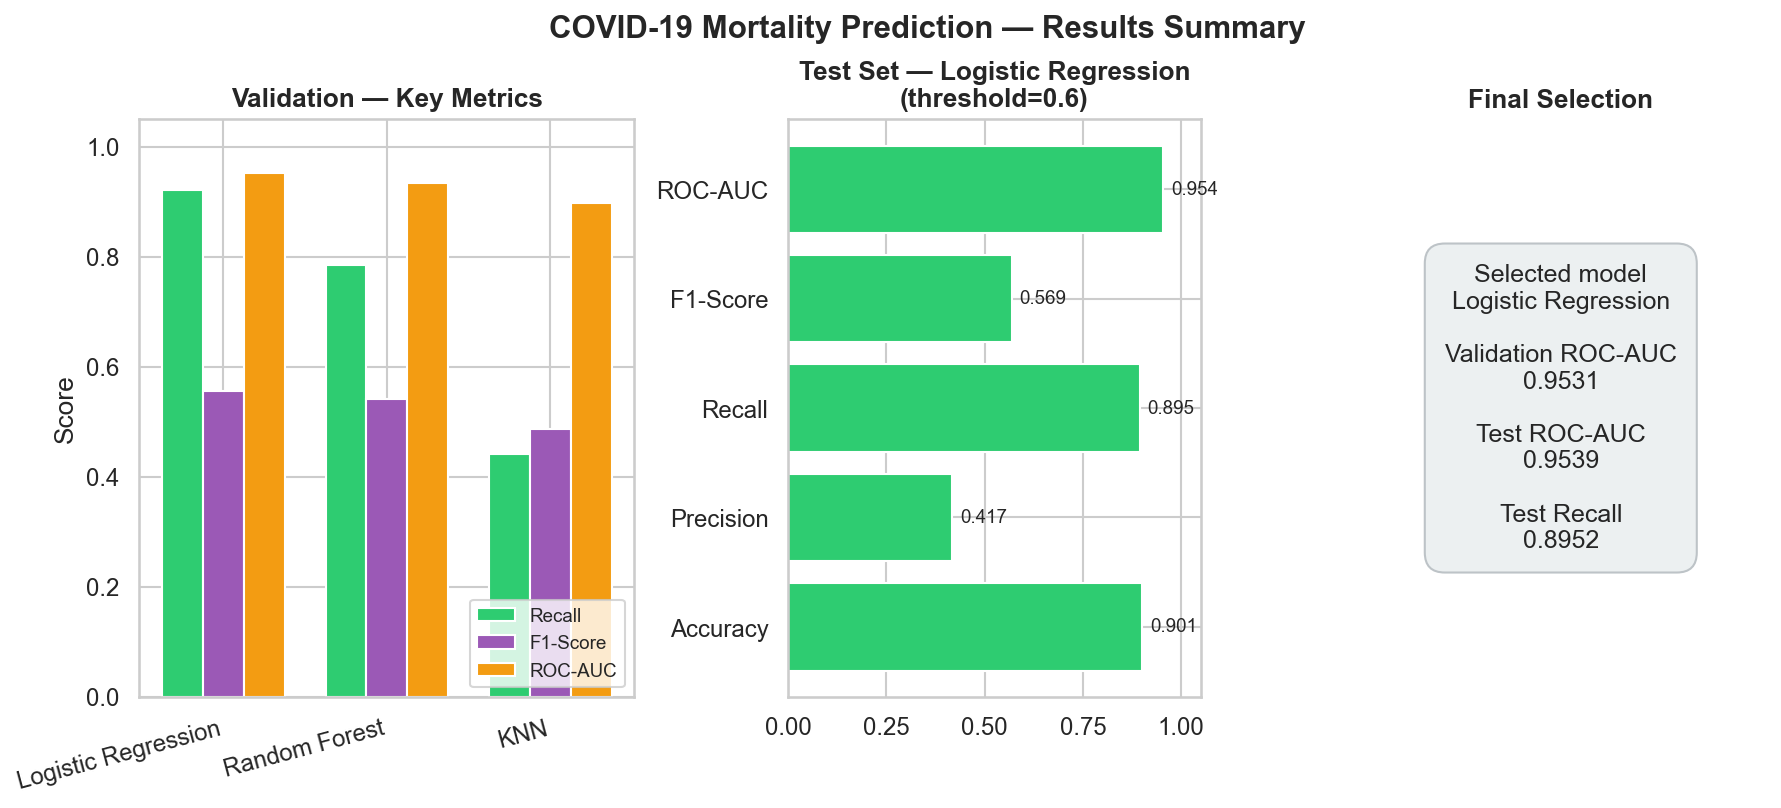

In [60]:
# Reuse results from validation; test metrics from final evaluation
test_metrics = {
    'Accuracy': test_acc, 'Precision': test_prec, 'Recall': test_rec,
    'F1-Score': test_f1, 'ROC-AUC': test_auc
}

fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1, 1], wspace=0.35)

# Validation metrics — grouped bar
ax0 = fig.add_subplot(gs[0, 0])
plot_df = results[['Recall', 'F1-Score', 'ROC-AUC']].copy()
x = np.arange(len(plot_df))
w = 0.25
for i, col in enumerate(plot_df.columns):
    ax0.bar(x + (i - 1) * w, plot_df[col], width=w, label=col, color=MODEL_COLORS[i % 3], edgecolor='white')
ax0.set_xticks(x)
ax0.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax0.set_ylim(0, 1.05)
ax0.set_ylabel('Score')
ax0.set_title('Validation — Key Metrics', fontweight='bold')
ax0.legend(loc='lower right', fontsize=9)
ax0.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)

# Final test — horizontal bars
ax1 = fig.add_subplot(gs[0, 1])
names = list(test_metrics.keys())
vals = list(test_metrics.values())
bars = ax1.barh(names, vals, color=MODEL_COLORS[0], edgecolor='white')
ax1.set_xlim(0, 1.05)
ax1.set_title(f'Test Set — {selected_model_name}\n(threshold={selected_threshold})', fontweight='bold')
for b, v in zip(bars, vals):
    ax1.text(v + 0.02, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)

# Highlight card
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
summary_text = (
    f'Selected model\n{selected_model_name}\n\n'
    f'Validation ROC-AUC\n{results.loc[selected_model_name, "ROC-AUC"]:.4f}\n\n'
    f'Test ROC-AUC\n{test_auc:.4f}\n\n'
    f'Test Recall\n{test_rec:.4f}'
)
ax2.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=12,
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#ecf0f1', edgecolor='#bdc3c7'))
ax2.set_title('Final Selection', fontweight='bold')

plt.suptitle('COVID-19 Mortality Prediction — Results Summary', fontsize=15, fontweight='bold', y=1.02)
plt.subplots_adjust(top=0.88)
plt.show()


### Why This Model and Threshold Were Selected

**Why recall matters most:**
In a medical-risk classification problem, a **false negative** (predicting "survived" when the patient actually dies) is far more dangerous than a false positive. Missing a high-risk patient could mean delayed treatment. A false alarm only leads to extra caution — acceptable in a medical context.

**Why the threshold was lowered:**
The default 0.5 threshold optimizes for balanced accuracy, but we need to prioritize catching death cases. Lowering the threshold increases recall at the cost of some precision — a worthwhile trade-off when lives are at stake.

**Why F1-score is the deciding metric:**
F1-score combines precision and recall into a single number. It ensures we don't sacrifice precision entirely while maximizing recall. A model with high recall but very low precision would flag too many healthy patients as high-risk.

### Important Disclaimer

This is an **educational machine learning project**. The models demonstrate the ML pipeline process but are **not validated for clinical use**. Real-world medical prediction systems require clinical validation, regulatory approval, and domain expert involvement.

### Limitations

- Some columns with high missing rates (ICU, INTUBED, PREGNANT) were dropped — they could carry useful signal
- No hyperparameter tuning was performed — default/simple configurations were used
- The dataset may contain biases from the original data collection process

### Potential Next Steps

- Hyperparameter tuning with GridSearchCV
- Calibration curves to assess probability reliability
- Fairness analysis across demographic groups